# Sprint 1 — Comprensión y Preparación
**Proyecto:** Clasificación de Tipos de Frijol (Dry Bean Dataset)  
**Dataset:** UCI ML Repository — ID 602  
**Objetivo del sprint:** Explorar el dataset, evaluar su calidad y dejarlo listo para el modelado.

---
### Tareas del Sprint
- [ ] Configurar entorno e instalar dependencias
- [ ] Explorar el dataset (forma, tipos, estadísticas)
- [ ] Evaluar calidad: nulos, duplicados, outliers
- [ ] Analizar distribución de clases
- [ ] Separar conjunto train/test
- [ ] Guardar dataset limpio

### Entregables
- Dataset limpio (`drybean_clean.csv`)
- Sets de entrenamiento y prueba (`X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`)
- Este notebook documentado

## 1. Configuración del entorno
Instala las dependencias necesarias. En un entorno virtual ejecuta primero:
```bash
pip install ucimlrepo scikit-learn pandas numpy matplotlib
```

In [1]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga del Dataset

In [3]:
dry_bean = fetch_ucirepo(id=602)
X = dry_bean.data.features
y = dry_bean.data.targets

df = pd.concat([X, y], axis=1)
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 13611 filas x 17 columnas


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 3. Exploración Inicial (EDA)
### 3.1 Estructura general

In [4]:
# Número de registros y variables
num_registros, num_variables = df.shape
nombre_objetivo = y.columns[0]

print(f"1. Registros totales  : {num_registros}")
print(f"2. Variables totales  : {num_variables}")
print(f"3. Variable objetivo  : '{nombre_objetivo}'")
print(f"4. Clases únicas      : {sorted(df[nombre_objetivo].unique())}")

1. Registros totales  : 13611
2. Variables totales  : 17
3. Variable objetivo  : 'Class'
4. Clases únicas      : ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [5]:
# Tipos de datos y estadísticas descriptivas
print("--- Tipos de datos ---")
print(df.dtypes.value_counts())
print()
df.describe()

--- Tipos de datos ---
float64    14
int64       2
object      1
Name: count, dtype: int64



,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [6]:
# Información completa del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

### 3.2 Detección de Outliers (método IQR)

In [7]:
df_numerico = df.select_dtypes(include=['float64', 'int64'])

Q1  = df_numerico.quantile(0.25)
Q3  = df_numerico.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_numerico < (Q1 - 1.5 * IQR)) | (df_numerico > (Q3 + 1.5 * IQR))).sum()
columnas_con_outliers = outliers[outliers > 0]

print("Columnas con outliers detectados (IQR):")
print(columnas_con_outliers.to_string())
print()
print("Decisión: se conservan — son medidas reales de granos atípicos.")

Columnas con outliers detectados (IQR):
Area               551
Perimeter          500
MajorAxisLength    379
MinorAxisLength    569
AspectRatio        473
Eccentricity       843
ConvexArea         550
EquivDiameter      526
Extent             275
Solidity           778
Roundness           91
Compactness        109
ShapeFactor1       533
ShapeFactor3       195
ShapeFactor4       767

Decisión: se conservan — son medidas reales de granos atípicos.


## 4. Calidad de Datos
### 4.1 Valores nulos y filas duplicadas

In [8]:
missing_values   = df.isna().sum()
duplicated_rows  = df.duplicated().sum()

print("Valores nulos por columna:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "  ✅ Ninguno")
print(f"\nFilas duplicadas: {duplicated_rows}")

Valores nulos por columna:
  ✅ Ninguno

Filas duplicadas: 68


### 4.2 Eliminación de duplicados

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicados eliminados.")
print(f"Tamaño del dataset limpio: {df.shape}")
print(f"Filas duplicadas restantes: {df.duplicated().sum()}")

Duplicados eliminados.
Tamaño del dataset limpio: (13543, 17)
Filas duplicadas restantes: 0


## 5. Análisis de la Variable Objetivo
### 5.1 Distribución de clases

In [10]:
class_counts = df["Class"].value_counts()
total = len(df)
porcentajes  = (class_counts / total * 100).round(2)

resumen_clases = pd.DataFrame({
    "Registros"   : class_counts,
    "Porcentaje %": porcentajes
})
print(resumen_clases.to_string())

ratio = porcentajes.max() / porcentajes.min()
print(f"\nRatio mayoritaria / minoritaria: {ratio:.1f}x")

          Registros  Porcentaje %
Class                            
DERMASON       3546         26.18
SIRA           2636         19.46
SEKER          2027         14.97
HOROZ          1860         13.73
CALI           1630         12.04
BARBUNYA       1322          9.76
BOMBAY          522          3.85

Ratio mayoritaria / minoritaria: 6.8x


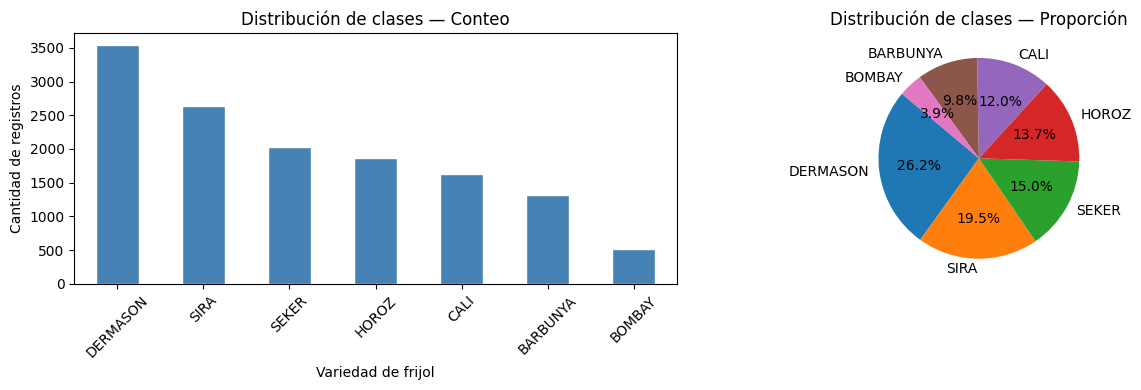

Gráfica guardada como 'distribucion_clases.png'


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barras
class_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de clases — Conteo")
axes[0].set_xlabel("Variedad de frijol")
axes[0].set_ylabel("Cantidad de registros")
axes[0].tick_params(axis='x', rotation=45)

# Pie
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title("Distribución de clases — Proporción")

plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'distribucion_clases.png'")

### 5.2 Conclusión sobre el balance

> **Las clases NO están balanceadas.** DERMASON tiene ~6x más registros que BOMBAY.  
> **Impacto en el modelado:**  
> - El modelo tenderá a predecir con mayor frecuencia las clases mayoritarias.  
> - Se usará **F1 Macro** como métrica principal (no Accuracy).  
> - En el Sprint 2 se aplicará `class_weight='balanced'` en Random Forest.

## 6. Separación Train / Test

In [12]:
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Preserva proporciones de clase
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print()
print("Proporción de clases en y_train:")
print((y_train.value_counts() / len(y_train) * 100).round(2).astype(str) + ' %')

X_train : (10834, 16)
X_test  : (2709, 16)
y_train : (10834,)
y_test  : (2709,)

Proporción de clases en y_train:
Class
DERMASON    26.19 %
SIRA        19.47 %
SEKER       14.96 %
HOROZ       13.73 %
CALI        12.04 %
BARBUNYA     9.76 %
BOMBAY       3.86 %
Name: count, dtype: object


## 7. Guardar Entregables del Sprint

In [13]:
df.to_csv("drybean_clean.csv", index=False)
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv",  index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv",  index=False)

print("Entregables guardados:")
print("drybean_clean.csv")
print("X_train.csv / X_test.csv")
print("y_train.csv / y_test.csv")
print("distribucion_clases.png")
print()
print("Sprint 1 completado. Continúa con: sprint2_modelado_evaluacion.ipynb")

Entregables guardados:
drybean_clean.csv
X_train.csv / X_test.csv
y_train.csv / y_test.csv
distribucion_clases.png

Sprint 1 completado. Continúa con: sprint2_modelado_evaluacion.ipynb
